In [ ]:
import pandas as pd
df=pd.read_csv('/content/Employee_Attrition.csv')
df

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


In [ ]:
col=df.pop('left')

In [ ]:
df['Target']=col

In [ ]:
df

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,Department,salary,Target
0,0.38,0.53,2,157,3,0,0,sales,low,1
1,0.80,0.86,5,262,6,0,0,sales,medium,1
2,0.11,0.88,7,272,4,0,0,sales,medium,1
3,0.72,0.87,5,223,5,0,0,sales,low,1
4,0.37,0.52,2,159,3,0,0,sales,low,1
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,0,support,low,1
14995,0.37,0.48,2,160,3,0,0,support,low,1
14996,0.37,0.53,2,143,3,0,0,support,low,1
14997,0.11,0.96,6,280,4,0,0,support,low,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   promotion_last_5years  14999 non-null  int64  
 7   Department             14999 non-null  object 
 8   salary                 14999 non-null  object 
 9   Target                 14999 non-null  int64  
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [ ]:
numerical_cols=['satisfaction_level','last_evaluation','number_project',
                'average_montly_hours','time_spend_company']

In [ ]:
categorical_cols=['Work_accident','promotion_last_5years','Department','salary','Target']

**INSIGHTS**

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: >

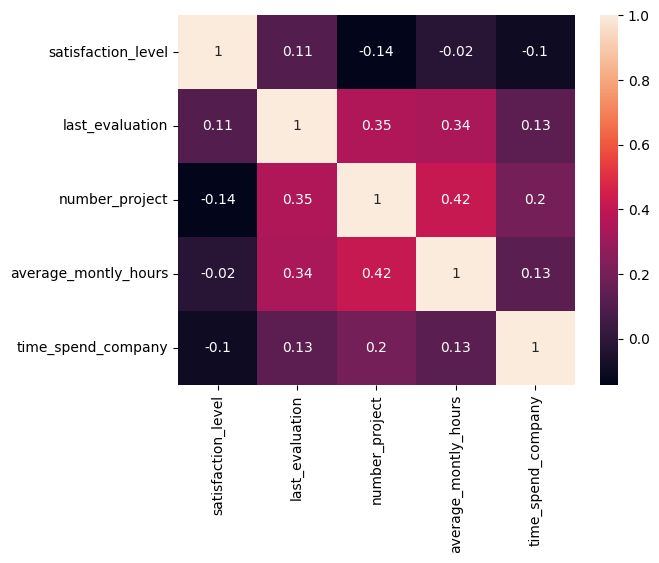

In [ ]:
sns.heatmap(df[numerical_cols].corr(),annot=True)

Employees handling more projects or staying longer are slightly less satisfied.

Higher evaluations are linked to more projects and longer working hours.

Those managing more projects usually work more hours.

Time spent at the company shows weak links with other factors.

<Figure size 1200x800 with 0 Axes>

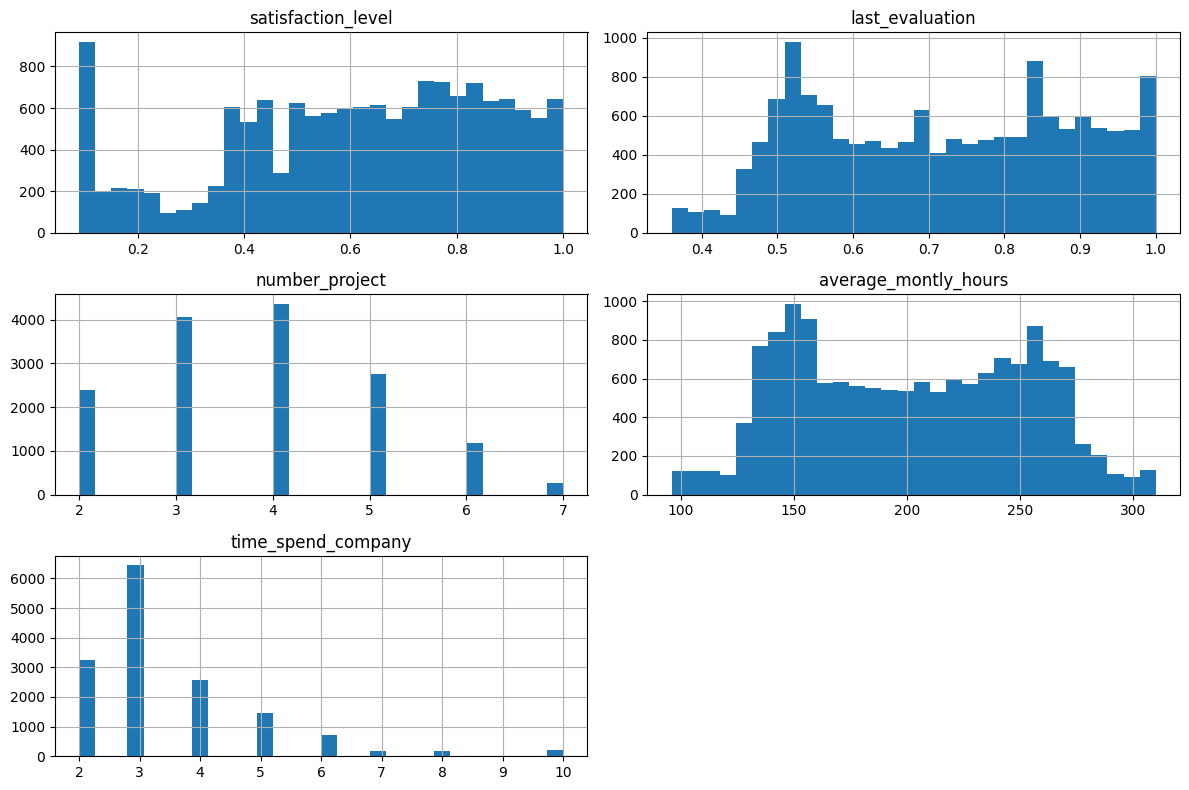

In [ ]:
plt.figure(figsize=(12,8))
df[numerical_cols].hist(bins=30,figsize=(12,8))
layout=(len(numerical_cols)//3 +1,3)
plt.tight_layout()
plt.show()

## INSIGHT 1 :
Many employees show low satisfaction, which increases their chances of leaving.

In performance evaluations, low scorers may quit due to poor results, while top performers may leave for better offers.

Most employees worked on 3–4 projects — too few leads to boredom, too many causes stress.

Work hours show two groups: underworked and overworked, both more likely to leave.

Finally, long-tenure employees leave for growth, while short-tenure ones leave due to early dissatisfaction.

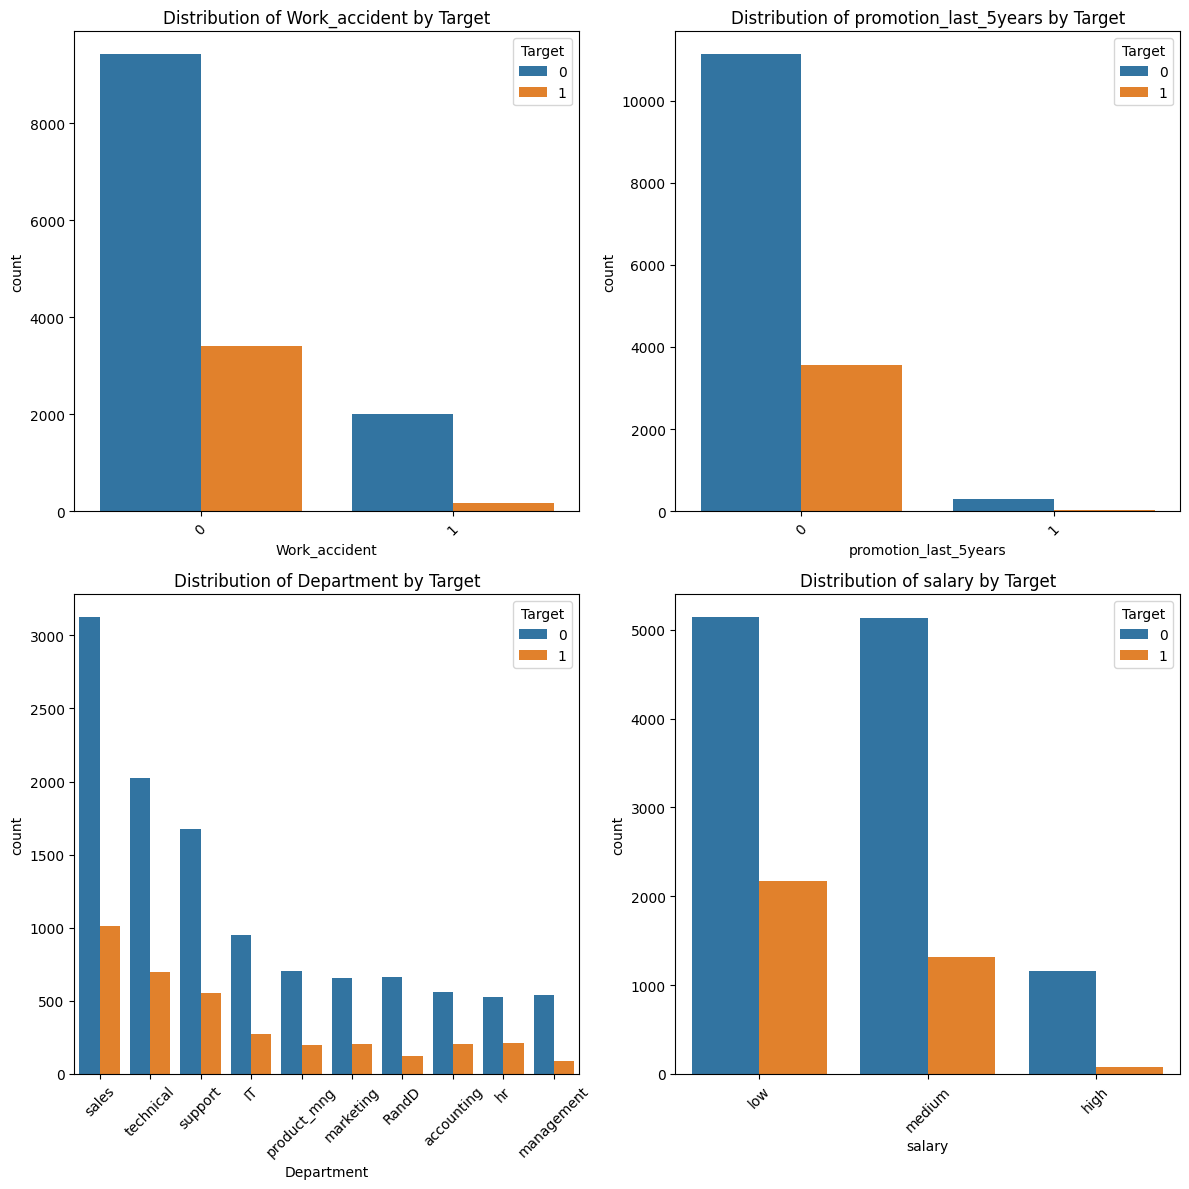

In [ ]:
target_var = 'Target'

if target_var in categorical_cols:
    cat_features = [col for col in categorical_cols if col != target_var]
    num_plots = len(cat_features)
    rows = (num_plots // 2) + (num_plots % 2)
    fig, axes = plt.subplots(rows, 2, figsize=(12, 6 * rows))
    axes = axes.flatten()

    for i, col in enumerate(cat_features):
        sns.countplot(data=df, x=col, hue=target_var, order=df[col].value_counts().index, ax=axes[i])
        axes[i].set_title(f"Distribution of {col} by {target_var}")
        axes[i].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()



INSIGHT 2:
Departments like Sales, Technical, and Support might have more employees but also possibly higher attrition.

Employees with low salaries may be more likely to leave compared to those with medium or high salaries.

Work accidents do not appear to be a major factor in employee attrition, as the number of employees who left after having an accident is quite small.

The majority of employees did not receive a promotion in the last five years which may indicate that lack of promotions might be a contributing factor to employees leaving.

In [ ]:
# if target_var in df.columns:
#   num_plots = len(numerical_cols)
#   rows = (num_plots // 2) + (num_plots % 2)
#   fig, axes = plt.subplots(rows, 2, figsize=(12, 6 * rows))
#   axes = axes.flatten()
#   for i, col in enumerate(numerical_cols):
#     sns.boxplot(data=df, x=target_var, y=col, ax=axes[i])
#     axes[i].set_title(f"Box Plot of {col} by {target_var}")
#   for j in range(i + 1, len(axes)):
#     fig.delaxes(axes[j])
# plt.tight_layout()

In [ ]:
df.select_dtypes(include=['O']).columns

Index(['Department', 'salary'], dtype='object')

In [ ]:
df['Department'].unique()

array(['sales', 'accounting', 'hr', 'technical', 'support', 'management',
       'IT', 'product_mng', 'marketing', 'RandD'], dtype=object)

In [ ]:
df['salary'].unique()

array(['low', 'medium', 'high'], dtype=object)

In [ ]:
df['Target'].value_counts()

,count
Target,
0,11428
1,3571


In [ ]:
from sklearn.preprocessing import LabelEncoder
cat_cols=['Department','salary']
encoders=[LabelEncoder() for i in cat_cols]
encoders
for i,col in enumerate(cat_cols):
  df[col]=encoders[i].fit_transform(df[col])
  print(encoders[i].classes_)
  print(list(enumerate(encoders[i].classes_)))


['IT' 'RandD' 'accounting' 'hr' 'management' 'marketing' 'product_mng'
 'sales' 'support' 'technical']
[(0, 'IT'), (1, 'RandD'), (2, 'accounting'), (3, 'hr'), (4, 'management'), (5, 'marketing'), (6, 'product_mng'), (7, 'sales'), (8, 'support'), (9, 'technical')]
['high' 'low' 'medium']
[(0, 'high'), (1, 'low'), (2, 'medium')]


In [ ]:
df

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,Department,salary,Target
0,0.38,0.53,2,157,3,0,0,7,1,1
1,0.80,0.86,5,262,6,0,0,7,2,1
2,0.11,0.88,7,272,4,0,0,7,2,1
3,0.72,0.87,5,223,5,0,0,7,1,1
4,0.37,0.52,2,159,3,0,0,7,1,1
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,0,8,1,1
14995,0.37,0.48,2,160,3,0,0,8,1,1
14996,0.37,0.53,2,143,3,0,0,8,1,1
14997,0.11,0.96,6,280,4,0,0,8,1,1


In [ ]:
X=df.iloc[:,:-1]
X

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,0,7,1
1,0.80,0.86,5,262,6,0,0,7,2
2,0.11,0.88,7,272,4,0,0,7,2
3,0.72,0.87,5,223,5,0,0,7,1
4,0.37,0.52,2,159,3,0,0,7,1
...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,0,8,1
14995,0.37,0.48,2,160,3,0,0,8,1
14996,0.37,0.53,2,143,3,0,0,8,1
14997,0.11,0.96,6,280,4,0,0,8,1


In [ ]:
y=df.iloc[:,-1]
y

,Target
0,1
1,1
2,1
3,1
4,1
...,...
14994,1
14995,1
14996,1
14997,1


In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
X_scaled=scaler.fit_transform(X)
X_scaled

array([[0.31868132, 0.265625  , 0.        , ..., 0.        , 0.77777778,
        0.5       ],
       [0.78021978, 0.78125   , 0.6       , ..., 0.        , 0.77777778,
        1.        ],
       [0.02197802, 0.8125    , 1.        , ..., 0.        , 0.77777778,
        1.        ],
       ...,
       [0.30769231, 0.265625  , 0.        , ..., 0.        , 0.88888889,
        0.5       ],
       [0.02197802, 0.9375    , 0.8       , ..., 0.        , 0.88888889,
        0.5       ],
       [0.30769231, 0.25      , 0.        , ..., 0.        , 0.88888889,
        0.5       ]])

In [ ]:
from imblearn.over_sampling import SMOTE
os=SMOTE(random_state=1)
X_os,y_os=os.fit_resample(X_scaled,y)

In [ ]:
y_os.value_counts()

,count
Target,
1,11428
0,11428


In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X_os,y_os,test_size=0.3,random_state=1)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report

models=[KNeighborsClassifier(),GaussianNB(),
        DecisionTreeClassifier(random_state=1),RandomForestClassifier(random_state=1),
        AdaBoostClassifier(random_state=1),GradientBoostingClassifier(random_state=1),XGBClassifier(),SVC()]
for model in models:
  print(model)
  print("*"*80)
  model.fit(X_train,y_train)
  y_pred=model.predict(X_test)
  print(classification_report(y_test,y_pred))

KNeighborsClassifier()
********************************************************************************
              precision    recall  f1-score   support

           0       0.98      0.94      0.96      3398
           1       0.94      0.98      0.96      3459

    accuracy                           0.96      6857
   macro avg       0.96      0.96      0.96      6857
weighted avg       0.96      0.96      0.96      6857

GaussianNB()
********************************************************************************
              precision    recall  f1-score   support

           0       0.87      0.53      0.66      3398
           1       0.67      0.92      0.77      3459

    accuracy                           0.73      6857
   macro avg       0.77      0.72      0.72      6857
weighted avg       0.77      0.73      0.72      6857

DecisionTreeClassifier(random_state=1)
********************************************************************************
              precision    r

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier()
rf.fit(X_train,y_train)

RandomForestClassifier()

In [ ]:
y_predrf=rf.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report,ConfusionMatrixDisplay
print(classification_report(y_test,y_predrf))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3398
           1       1.00      0.98      0.99      3459

    accuracy                           0.99      6857
   macro avg       0.99      0.99      0.99      6857
weighted avg       0.99      0.99      0.99      6857



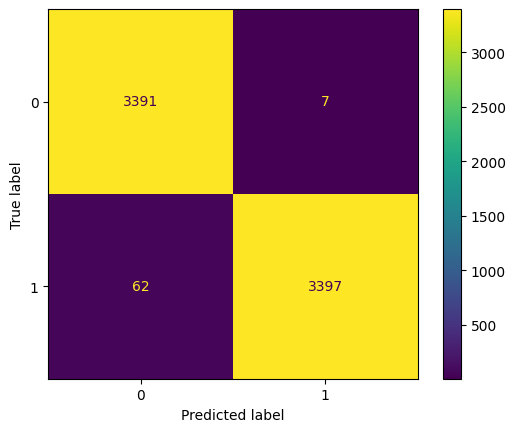

In [ ]:
print(ConfusionMatrixDisplay.from_predictions(y_test,y_predrf))

In [ ]:
y_new=rf.predict(scaler.transform([[0.38,0.53,2,157,3,0,0,7,1]]))
if y_new==1:
  print("Employee is likely to stay")
else:
  print("Employee is likely to leave")

Employee is likely to stay


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [ ]:
for i,col in enumerate(cat_cols):
  df[col]=encoders[i].inverse_transform(df[col])
df

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,Department,salary,Target
0,0.38,0.53,2,157,3,0,0,sales,low,1
1,0.80,0.86,5,262,6,0,0,sales,medium,1
2,0.11,0.88,7,272,4,0,0,sales,medium,1
3,0.72,0.87,5,223,5,0,0,sales,low,1
4,0.37,0.52,2,159,3,0,0,sales,low,1
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,0,support,low,1
14995,0.37,0.48,2,160,3,0,0,support,low,1
14996,0.37,0.53,2,143,3,0,0,support,low,1
14997,0.11,0.96,6,280,4,0,0,support,low,1


In [ ]:
import pickle
pickle.dump(rf,open('modelrf.sav','wb'))

In [ ]:
pickle.dump(scaler,open('scalerrf.sav','wb'))

In [ ]:
# Save each encoder for later use in Streamlit
with open('encoders.pkl', 'wb') as f:
    pickle.dump(encoders, f)

Model: KNN
********************************************************************************
              precision    recall  f1-score   support

           0       0.98      0.94      0.96      3398
           1       0.94      0.98      0.96      3459

    accuracy                           0.96      6857
   macro avg       0.96      0.96      0.96      6857
weighted avg       0.96      0.96      0.96      6857



Model: Naive Bayes
********************************************************************************
              precision    recall  f1-score   support

           0       0.87      0.53      0.66      3398
           1       0.67      0.92      0.77      3459

    accuracy                           0.73      6857
   macro avg       0.77      0.72      0.72      6857
weighted avg       0.77      0.73      0.72      6857



Model: Decision Tree
********************************************************************************
              precision    recall  f1-score   su

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [06:06:16] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3398
           1       1.00      0.98      0.99      3459

    accuracy                           0.99      6857
   macro avg       0.99      0.99      0.99      6857
weighted avg       0.99      0.99      0.99      6857



Model: SVM
********************************************************************************
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      3398
           1       0.95      0.93      0.94      3459

    accuracy                           0.94      6857
   macro avg       0.94      0.94      0.94      6857
weighted avg       0.94      0.94      0.94      6857





/tmp/ipython-input-1268428764.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Accuracy", y="Model", data=results_df, palette="viridis")


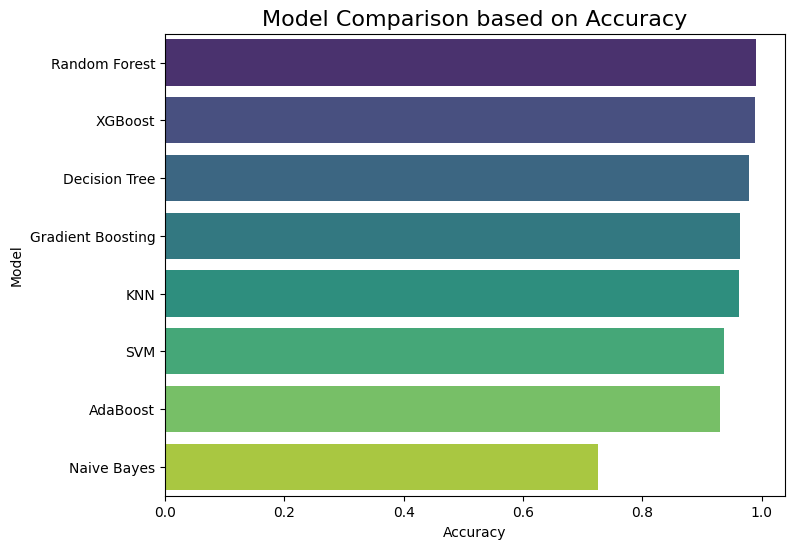

In [ ]:
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix

# List of models
models = [
    ("KNN", KNeighborsClassifier()),
    ("Naive Bayes", GaussianNB()),
    ("Decision Tree", DecisionTreeClassifier(random_state=1)),
    ("Random Forest", RandomForestClassifier(random_state=1)),
    ("AdaBoost", AdaBoostClassifier(random_state=1)),
    ("Gradient Boosting", GradientBoostingClassifier(random_state=1)),
    ("XGBoost", XGBClassifier(use_label_encoder=False, eval_metric='logloss')),
    ("SVM", SVC())
]

# Store results
results = []

# Training and evaluation
for name, model in models:
    print(f"Model: {name}")
    print("*" * 80)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append((name, acc))
    print(classification_report(y_test, y_pred))
    print("\n")

# Convert results to DataFrame for easy plotting
import pandas as pd
results_df = pd.DataFrame(results, columns=["Model", "Accuracy"]).sort_values(by="Accuracy", ascending=False)

# --- Plot comparison ---
plt.figure(figsize=(8,6))
sns.barplot(x="Accuracy", y="Model", data=results_df, palette="viridis")
plt.title("Model Comparison based on Accuracy", fontsize=16)
plt.xlabel("Accuracy")
plt.ylabel("Model")
plt.show()

1.Job Satisfaction Matters
* Finding: Employees who aren’t happy with their jobs are more likely to leave.
* Strategy: Regularly ask employees how they feel about their jobs and act on their
feedback. Recognize their efforts, offer chances to grow, and allow flexible working
options.


2.Work-Life Balance is Important
* Finding: Employees working too much or too little are more likely to quit.
* Strategy: Make sure employees have a healthy work-life balance. Allow flexible work
hours, remote work, and wellness programs.


3.High Performers May Leave
* Finding: Even top employees leave when they don’t see career growth.
* Strategy: Give them clear career paths, mentorship programs, and leadership training to
help them grow within the company.


4.Salary Impacts Retention
* Finding: Employees with lower salaries leave more often.
* Strategy: Regularly check industry pay standards and adjust salaries to stay competitive.
Provide bonuses and stock options to keep employees motivated.


5.Promotions Matter
* Finding: Employees who don’t get promoted tend to leave.
* Strategy: Be transparent about how promotions work. Offer regular skill development
and training so employees feel they have opportunities to grow